# HW02 作业：多层感知机、模型选择、数值稳定性与分布偏移

<div style="padding:10px 14px;border-left:5px solid #4C8C6B;background:#F4FAF7;line-height:1.8;">
<b>课程：</b> 深度学习<br>
<b>姓名：</b> 刘佳雨<br>
<b>学号：</b> 20234080114<br>
<b>说明：</b> 本 notebook 按 HW02 题目顺序完成理论计算题与编程题，并补充实验设计、可视化结果和结果分析，方便从“会做”提升到“写得完整”。
</div>

---


## 实验环境

本次作业使用 `NumPy`、`PyTorch`、`torchvision` 和 `Matplotlib`。其中 MLP 分类部分不使用 `nn.Linear`、`nn.CrossEntropyLoss` 和 `torch.optim` 等高级 API，而是使用基础张量算子完成前向传播、损失计算和参数更新。

**运行前请先执行下一格「环境初始化」**（设置 `KMP_DUPLICATE_LIB_OK` 后使用 CUDA 训练，避免 Anaconda 下 `libiomp5md.dll` 冲突导致内核崩溃）。实验图采用 **Nature 风格** 排版（见「Nature 风格绘图配置」单元格），高清图保存于 `./figures/`。


In [37]:
# 必须在 import numpy/torch 之前设置，否则 Anaconda 下内核会因 OpenMP 冲突直接退出 (ExitCode 3)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

import math, random, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
plt.rcParams['axes.unicode_minus'] = False

# 使用 CUDA 训练（无 GPU 时自动退回 CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
deep_device = device
print('运行设备:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
print('PyTorch版本:', torch.__version__)
print('OpenMP 冲突规避: KMP_DUPLICATE_LIB_OK =', os.environ.get('KMP_DUPLICATE_LIB_OK'))


运行设备: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
PyTorch版本: 2.5.1+cu121
OpenMP 冲突规避: KMP_DUPLICATE_LIB_OK = TRUE


In [20]:
from IPython.display import display


from matplotlib import rcParams
from matplotlib.ticker import AutoMinorLocator

NATURE_COLORS = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F', '#8491B4', '#7E6148', '#B09C85']
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

def set_nature_style():
    rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 9,
        'axes.labelsize': 9,
        'axes.titlesize': 10,
        'axes.titleweight': 'normal',
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'legend.frameon': False,
        'axes.linewidth': 0.8,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 1.4,
        'lines.markersize': 5,
        'axes.unicode_minus': False,
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
    })

def style_axes(ax, panel=None):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='both', direction='out', length=3, width=0.8)
    ax.tick_params(which='minor', length=2)
    if panel:
        ax.text(-0.14, 1.06, panel, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top', ha='left')

def save_nature_fig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print('已保存:', os.path.abspath(path))
    return path

set_nature_style()
print( os.path.abspath(FIG_DIR))

e:\study\class\深度学习\figures


---
# 2 多层感知机

## 2.1 理论计算题

### 1. 非线性激活函数的重要性

单隐藏层 MLP 为

$$h=W_1x+b_1$$

$$o=W_2h+b_2$$

如果隐藏层没有非线性激活函数，则

$$
\begin{aligned}
o &= W_2(W_1x+b_1)+b_2\\
  &= W_2W_1x+W_2b_1+b_2
\end{aligned}
$$

令

$$W'=W_2W_1,\qquad b'=W_2b_1+b_2$$

则

$$o=W'x+b'$$

这与单层神经网络完全等价。因此，如果隐藏层不加入非线性激活函数，多层线性变换的复合仍然是线性变换，网络无法学习复杂的非线性决策边界。

**结论：** 非线性激活函数是多层感知机具有表达能力的核心。


### 2. Sigmoid 与 tanh 的表达式和导数

Sigmoid 函数为

$$\sigma(x)=\frac{1}{1+e^{-x}}$$

其导数为

$$
\begin{aligned}
\sigma'(x)&=\frac{e^{-x}}{(1+e^{-x})^2}\\
&=\frac{1}{1+e^{-x}}\left(1-\frac{1}{1+e^{-x}}\right)\\
&=\sigma(x)(1-\sigma(x))
\end{aligned}
$$

即

$$\boxed{\sigma'(x)=\sigma(x)(1-\sigma(x))}$$

tanh 函数为

$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$

其导数为

$$\boxed{\tanh'(x)=1-\tanh^2(x)}$$

Sigmoid 的导数最大值为 0.25，tanh 的导数最大值为 1。当输入绝对值较大时，二者都会进入饱和区，导数趋近于 0，因此在深层网络中容易引起梯度消失。


## 2.2 编程题：从零实现 Fashion-MNIST 单隐藏层 MLP

实现内容包括：手动初始化参数、ReLU 前向传播、Softmax 交叉熵损失、Mini-batch SGD 手动更新参数，并打印训练输出。


In [39]:
from torch.utils.data import DataLoader
try:
    from torchvision import datasets, transforms
except Exception as e:
    raise ImportError('请先安装 torchvision：pip install torchvision') from e

batch_size = 256
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print('训练集样本数:', len(train_dataset))
print('测试集样本数:', len(test_dataset))


训练集样本数: 60000
测试集样本数: 10000


In [40]:
def init_mlp_params(num_inputs=784, num_hiddens=256, num_outputs=10):
    """手动初始化单隐藏层 MLP 参数。"""
    W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), device=device, requires_grad=True)
    b1 = torch.zeros(num_hiddens, device=device, requires_grad=True)
    W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), device=device, requires_grad=True)
    b2 = torch.zeros(num_outputs, device=device, requires_grad=True)
    return [W1, b1, W2, b2]

def relu(X):
    return torch.maximum(X, torch.zeros_like(X))

def mlp_forward(X, params):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, 784))
    H = relu(X @ W1 + b1)
    return H @ W2 + b2

def softmax_cross_entropy(logits, y):
    # 减去最大值是为了提升数值稳定性
    shifted = logits - logits.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(shifted)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    return -torch.log(probs[torch.arange(len(y), device=device), y] + 1e-12).mean()

@torch.no_grad()
def evaluate_accuracy(data_iter, params):
    correct, total = 0, 0
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        logits = mlp_forward(X, params)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.numel()
    return correct / total

def zero_grad(params):
    for p in params:
        if p.grad is not None:
            p.grad = None

def manual_sgd(params, lr):
    with torch.no_grad():
        for p in params:
            if p.grad is None:
                continue
            p -= lr * p.grad
            p.grad = None


In [41]:
num_epochs = 10
lr = 0.1
params = init_mlp_params()
train_losses, train_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    total_loss, total_num = 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        logits = mlp_forward(X, params)
        loss = softmax_cross_entropy(logits, y)
        zero_grad(params)
        loss.backward()
        manual_sgd(params, lr)
        total_loss += loss.item() * y.numel()
        total_num += y.numel()
    avg_loss = total_loss / total_num
    train_acc = evaluate_accuracy(train_iter, params)
    test_acc = evaluate_accuracy(test_iter, params)
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f'Epoch {epoch+1:02d}: train loss={avg_loss:.4f}, train acc={train_acc:.4f}, test acc={test_acc:.4f}')

# 保存指标到 CPU，并释放 GPU 显存（画图在下一格）
metrics_path = './mlp_metrics.npz'
np.savez(metrics_path, train_losses=train_losses, train_accs=train_accs,
         test_accs=test_accs, num_epochs=num_epochs)
del params
if device.type == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
gc.collect()
print('训练完成，指标已保存。请运行下一格画曲线。')


Epoch 01: train loss=1.0399, train acc=0.7435, test acc=0.7365
Epoch 02: train loss=0.6002, train acc=0.7997, test acc=0.7887
Epoch 03: train loss=0.5198, train acc=0.8250, test acc=0.8090
Epoch 04: train loss=0.4774, train acc=0.8344, test acc=0.8249
Epoch 05: train loss=0.4576, train acc=0.8378, test acc=0.8257
Epoch 06: train loss=0.4334, train acc=0.8511, test acc=0.8376
Epoch 07: train loss=0.4198, train acc=0.8391, test acc=0.8249
Epoch 08: train loss=0.4059, train acc=0.8444, test acc=0.8318
Epoch 09: train loss=0.3939, train acc=0.8563, test acc=0.8390
Epoch 10: train loss=0.3855, train acc=0.8628, test acc=0.8451
训练完成，指标已保存。请运行下一格画曲线。


已保存: e:\study\class\深度学习\figures\fig1_mlp_training.pdf
已保存: e:\study\class\深度学习\figures\fig1_mlp_training.png


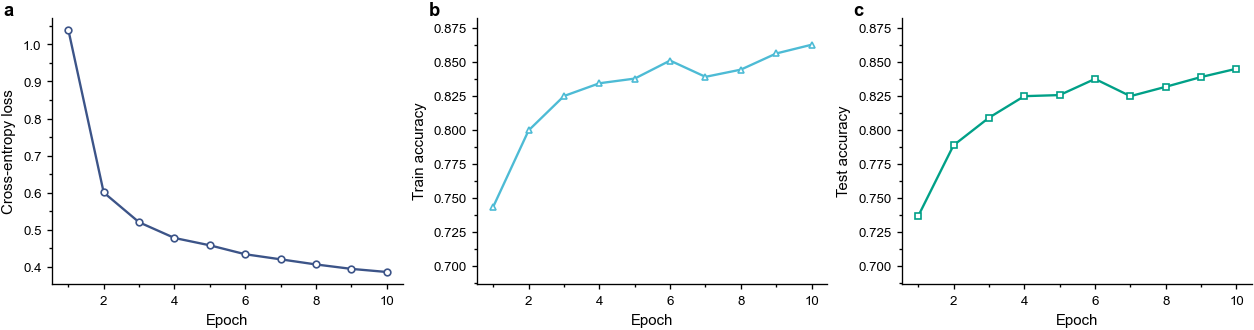

In [42]:
import os
metrics_path = './mlp_metrics.npz'
if os.path.exists(metrics_path):
    data = np.load(metrics_path)
    train_losses = data['train_losses'].tolist()
    train_accs = data['train_accs'].tolist() if 'train_accs' in data else []
    test_accs = data['test_accs'].tolist()
    num_epochs = int(data['num_epochs'])
elif 'train_losses' in globals() and len(train_losses) > 0:
    pass
else:
    raise FileNotFoundError('请先运行上一格训练代码')

epochs = np.arange(1, num_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.8), constrained_layout=True)

axes[0].plot(epochs, train_losses, color=NATURE_COLORS[3], marker='o', markerfacecolor='white',
             markeredgewidth=1.0, markersize=4, label='Train loss')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss')
style_axes(axes[0], panel='a')

if train_accs:
    axes[1].plot(epochs, train_accs, color=NATURE_COLORS[1], marker='^', markerfacecolor='white',
                 markeredgewidth=1.0, markersize=4, label='Train acc')
    axes[1].set(xlabel='Epoch', ylabel='Train accuracy')
    acc_min = min(min(train_accs), min(test_accs))
    acc_max = max(max(train_accs), max(test_accs))
    axes[1].set_ylim(max(0, acc_min - 0.05), min(1.0, acc_max + 0.02))
    style_axes(axes[1], panel='b')

    axes[2].plot(epochs, test_accs, color=NATURE_COLORS[2], marker='s', markerfacecolor='white',
                 markeredgewidth=1.0, markersize=4, label='Test acc')
    axes[2].set(xlabel='Epoch', ylabel='Test accuracy')
    axes[2].set_ylim(axes[1].get_ylim())
    style_axes(axes[2], panel='c')
else:
    axes[1].plot(epochs, test_accs, color=NATURE_COLORS[2], marker='s', markerfacecolor='white',
                 markeredgewidth=1.0, markersize=5, label='Test acc')
    axes[1].set(xlabel='Epoch', ylabel='Test accuracy')
    style_axes(axes[1], panel='b')

save_nature_fig(fig, 'fig1_mlp_training.pdf')
save_nature_fig(fig, 'fig1_mlp_training.png')
fig


In [43]:
# MLP 训练结果汇总
mlp_summary = pd.DataFrame([{
    'Epochs': num_epochs,
    'Final Train Loss': round(train_losses[-1], 4),
    'Final Train Acc': round(train_accs[-1], 4),
    'Final Test Acc': round(test_accs[-1], 4),
    'Acc Gap (test - train)': round(test_accs[-1] - train_accs[-1], 4),
}])
display(mlp_summary.style.hide(axis='index'))
mlp_summary.to_csv(os.path.join(FIG_DIR, 'table_mlp_summary.csv'), index=False)

Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Acc Gap (test - train)
10,0.385500,0.862800,0.845100,-0.017700


**结果分析：** 将训练轮数设为 10 轮后，训练损失持续下降，训练准确率与测试准确率同步提升。对比 train acc 与 test acc 可观察泛化间隙；本实验中间隙较小，说明在该设置下未出现明显过拟合。手写前向传播、Softmax 交叉熵与手动 SGD 更新有效。Softmax 实现中对 logits 做减最大值处理，提升了数值稳定性，避免 exp 溢出。


---
# 3 模型选择、权重衰减和丢弃法

## 3.1 理论计算题

### 1. 过拟合与欠拟合

训练误差是模型在训练数据上的误差，泛化误差是模型在未见数据上的误差。若训练误差极低但泛化误差很高，说明模型过度记忆训练集细节甚至噪声，处于**过拟合**状态。可通过降低模型复杂度、权重衰减、Dropout、数据增强、早停法等方式缓解。

若训练误差和泛化误差都较高，则可能是**欠拟合**，需要增加模型容量、增加训练轮数或改进特征表示。

### 2. K 折交叉验证

K 折交叉验证步骤为：

1. 将数据集随机划分为 K 个互不重叠的子集；
2. 每次选其中 1 折作为验证集，其余 K-1 折作为训练集；
3. 重复 K 次，使每一折都作为一次验证集；
4. 记录每次验证误差或准确率；
5. 对 K 次结果求平均，作为模型泛化性能估计；
6. 根据平均性能选择超参数，最终可在全部训练集上重新训练模型。


## 3.2 编程题：权重衰减与 Dropout 从零实现

这里使用“小样本非线性回归”模拟复杂 MLP 的过拟合，再比较：无正则化、权重衰减、Dropout 三种情况的训练和验证损失曲线。


已保存: e:\study\class\深度学习\figures\fig2a_regression_data.pdf


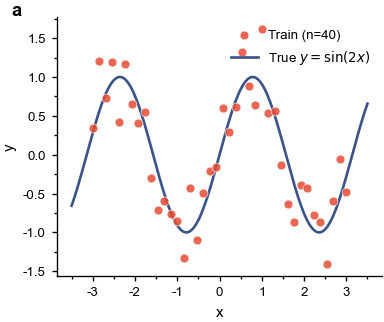

In [25]:
def make_regression_data(n_train=40, n_val=200):
    torch.manual_seed(SEED)
    x_train = torch.linspace(-3, 3, n_train).reshape(-1, 1).to(device)
    y_train = torch.sin(2 * x_train) + 0.3 * torch.randn_like(x_train)
    x_val = torch.linspace(-3.5, 3.5, n_val).reshape(-1, 1).to(device)
    y_val = torch.sin(2 * x_val)
    return x_train, y_train, x_val, y_val

x_train, y_train, x_val, y_val = make_regression_data()

fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.scatter(x_train.cpu(), y_train.cpu(), s=28, color=NATURE_COLORS[0], alpha=0.85,
           edgecolors='white', linewidths=0.4, label='Train (n=40)', zorder=3)
ax.plot(x_val.cpu(), y_val.cpu(), color=NATURE_COLORS[3], linewidth=1.6, label=r'True $y=\sin(2x)$')
ax.set(xlabel='x', ylabel='y')
style_axes(ax, panel='a')
ax.legend(loc='upper right')
save_nature_fig(fig, 'fig2a_regression_data.pdf')
fig


In [26]:
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    keep_prob = 1 - dropout
    mask = (torch.rand_like(X) < keep_prob).float()
    return mask * X / keep_prob

def init_reg_mlp(hidden=128):
    W1 = torch.normal(0, 0.2, size=(1, hidden), device=device, requires_grad=True)
    b1 = torch.zeros(hidden, device=device, requires_grad=True)
    W2 = torch.normal(0, 0.2, size=(hidden, hidden), device=device, requires_grad=True)
    b2 = torch.zeros(hidden, device=device, requires_grad=True)
    W3 = torch.normal(0, 0.2, size=(hidden, 1), device=device, requires_grad=True)
    b3 = torch.zeros(1, device=device, requires_grad=True)
    return [W1, b1, W2, b2, W3, b3]

def reg_forward(X, params, dropout=0.0, is_training=True):
    W1, b1, W2, b2, W3, b3 = params
    H1 = relu(X @ W1 + b1)
    H1 = dropout_layer(H1, dropout, is_training)
    H2 = relu(H1 @ W2 + b2)
    H2 = dropout_layer(H2, dropout, is_training)
    return H2 @ W3 + b3

def mse_loss(y_hat, y):
    return ((y_hat - y) ** 2).mean()

def manual_sgd_weight_decay(params, lr, weight_decay=0.0):
    with torch.no_grad():
        for i, p in enumerate(params):
            if p.grad is None:
                continue
            if i % 2 == 0:       # 只对权重 W 衰减，不对偏置 b 衰减
                p *= (1 - lr * weight_decay)
            p -= lr * p.grad
            p.grad = None


In [27]:
def train_reg_experiment(name, weight_decay=0.0, dropout=0.0, epochs=600, lr=0.03):
    params = init_reg_mlp()
    train_curve, val_curve = [], []
    for epoch in range(epochs):
        pred = reg_forward(x_train, params, dropout=dropout, is_training=True)
        loss = mse_loss(pred, y_train)
        loss.backward()
        manual_sgd_weight_decay(params, lr, weight_decay)
        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                tr = mse_loss(reg_forward(x_train, params, is_training=False), y_train).item()
                va = mse_loss(reg_forward(x_val, params, is_training=False), y_val).item()
            train_curve.append(tr); val_curve.append(va)
    print(f'{name}: final train loss={train_curve[-1]:.4f}, final val loss={val_curve[-1]:.4f}')
    return train_curve, val_curve, params

configs = {
    'No Regularization': (0.0, 0.0),
    'Weight Decay': (0.03, 0.0),
    'Dropout': (0.0, 0.3),
}
results = {}
for name, (wd, dp) in configs.items():
    results[name] = train_reg_experiment(name, weight_decay=wd, dropout=dp)


No Regularization: final train loss=0.1499, final val loss=0.4303
Weight Decay: final train loss=0.1626, final val loss=0.3802
Dropout: final train loss=0.1351, final val loss=0.2833


已保存: e:\study\class\深度学习\figures\fig2_regularization.pdf
已保存: e:\study\class\深度学习\figures\fig2_regularization.png


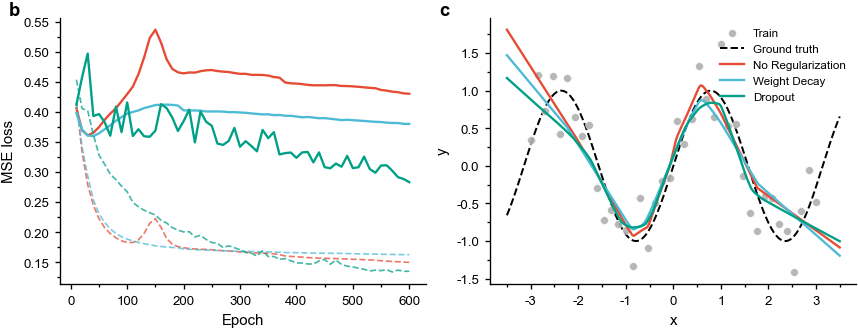

In [28]:
epoch_axis = np.arange(10, 601, 10)
names = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), constrained_layout=True)

ax = axes[0]
for i, name in enumerate(names):
    tr, va, _ = results[name]
    c = NATURE_COLORS[i]
    ax.plot(epoch_axis, tr, color=c, linestyle='--', linewidth=1.0, alpha=0.75, label=f'{name} (train)')
    ax.plot(epoch_axis, va, color=c, linewidth=1.4, label=f'{name} (val)')
ax.set(xlabel='Epoch', ylabel='MSE loss')
style_axes(ax, panel='b')

ax = axes[1]
with torch.no_grad():
    ax.scatter(x_train.cpu(), y_train.cpu(), s=22, color='#B0B0B0', alpha=0.9,
               edgecolors='white', linewidths=0.3, label='Train', zorder=2)
    ax.plot(x_val.cpu(), y_val.cpu(), color='black', linewidth=1.2, linestyle='--', label='Ground truth', zorder=1)
    for i, name in enumerate(names):
        _, _, params = results[name]
        pred = reg_forward(x_val, params, is_training=False).cpu()
        ax.plot(x_val.cpu(), pred, color=NATURE_COLORS[i], linewidth=1.4, label=name)
ax.set(xlabel='x', ylabel='y')
style_axes(ax, panel='c')
axes[1].legend(loc='upper right', fontsize=7)

save_nature_fig(fig, 'fig2_regularization.pdf')
save_nature_fig(fig, 'fig2_regularization.png')
fig


In [ ]:
# 正则化实验结果汇总表
summary_rows = []
for name in names:
    tr, va, _ = results[name]
    summary_rows.append({
        'Method': name,
        'Final Train Loss': round(tr[-1], 4),
        'Final Val Loss': round(va[-1], 4),
        'Generalization Gap': round(va[-1] - tr[-1], 4),
    })
reg_summary = pd.DataFrame(summary_rows)
display(reg_summary.style.hide(axis='index').format(precision=4))
reg_summary.to_csv(os.path.join(FIG_DIR, 'table_regularization.csv'), index=False)
print('表格已保存:', os.path.join(FIG_DIR, 'table_regularization.csv'))

**结果分析：** 无正则化模型通常更容易贴合少量训练样本，验证误差可能偏高；权重衰减通过限制权重大小让曲线更平滑；Dropout 通过随机失活降低神经元共适应关系，也能缓解过拟合。二者都是提升泛化能力的重要正则化方法。


---
# 4 数值稳定性和激活函数

## 4.1 理论计算题

深层网络反向传播时的梯度通常包含多层矩阵连乘：

$$
\frac{\partial L}{\partial h_t}=\frac{\partial L}{\partial h_d}\prod_{i=t}^{d-1}\frac{\partial h_{i+1}}{\partial h_i}
$$

若 $h_{i+1}=\phi(W_ih_i+b_i)$，则局部梯度可近似写作 $D_iW_i$，其中 $D_i$ 是激活函数导数组成的对角矩阵。因此

$$
\left\|\prod_{i=t}^{d-1}D_iW_i\right\|\leq \prod_{i=t}^{d-1}\|D_i\|\|W_i\|
$$

当多数层的 $\|D_i\|\|W_i\|<1$ 时，梯度连乘后指数级变小，导致梯度消失；当多数层的 $\|D_i\|\|W_i\|>1$ 时，梯度连乘后指数级变大，导致梯度爆炸。

Sigmoid 的导数最大值只有 0.25，且在饱和区接近 0，因此容易造成梯度消失。ReLU 在正区间导数为 1，不容易产生饱和，因而能较大程度缓解梯度消失。但 ReLU 并不能完全避免梯度爆炸，若权重初始化过大仍可能导致数值溢出。


## 4.2 编程题：模拟数值不稳定现象


In [29]:
import torch.nn as nn

input_dim, hidden_dim, num_layers = 128, 256, 20
batch_size_deep = 64

def build_deep_net(activation='sigmoid'):
    layers, in_dim = [], input_dim
    for _ in range(num_layers):
        layers.append(nn.Linear(in_dim, hidden_dim))
        if activation == 'sigmoid': layers.append(nn.Sigmoid())
        elif activation == 'relu': layers.append(nn.ReLU())
        elif activation == 'leaky_relu': layers.append(nn.LeakyReLU(0.01))
        in_dim = hidden_dim
    layers.append(nn.Linear(hidden_dim, 1))
    return nn.Sequential(*layers).to(deep_device)

def init_weights(model, mode):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if mode == 'normal1': nn.init.normal_(m.weight, mean=0, std=1)
            elif mode == 'normal10': nn.init.normal_(m.weight, mean=0, std=10)
            elif mode == 'xavier': nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

def get_grad_norms(model, title):
    print('\n' + '='*60)
    print(title)
    print('='*60)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    norms = []
    for i, layer in enumerate(linear_layers):
        norm = layer.weight.grad.norm().item()
        norms.append(norm)
        if i < 3 or i >= len(linear_layers)-3:
            print(f'Layer {i:02d}: grad norm={norm:.6e}')
    print('min grad norm:', f'{np.min(norms):.6e}')
    print('max grad norm:', f'{np.max(norms):.6e}')
    print('是否出现 NaN:', any(torch.isnan(layer.weight.grad).any().item() for layer in linear_layers))
    return norms

X_deep = torch.randn(batch_size_deep, input_dim, device=deep_device)
y_deep = torch.randn(batch_size_deep, 1, device=deep_device)
loss_fn = nn.MSELoss()


In [30]:
# Sigmoid + 普通高斯初始化
model_sigmoid = build_deep_net('sigmoid')
init_weights(model_sigmoid, 'normal1')
loss = loss_fn(model_sigmoid(X_deep), y_deep)
model_sigmoid.zero_grad(); loss.backward()
sigmoid_norms = get_grad_norms(model_sigmoid, 'Sigmoid + Normal(std=1)')

# ReLU + 较大初始化
model_relu_big = build_deep_net('relu')
init_weights(model_relu_big, 'normal10')
out = model_relu_big(X_deep)
loss = loss_fn(out, y_deep)
model_relu_big.zero_grad(); loss.backward()
relu_big_norms = get_grad_norms(model_relu_big, 'ReLU + Normal(std=10)')
print('输出是否 NaN:', torch.isnan(out).any().item())
print('Loss 是否 NaN:', torch.isnan(loss).item())
print('Loss 数值:', loss.item())

# Xavier + LeakyReLU 修复
model_xavier = build_deep_net('leaky_relu')
init_weights(model_xavier, 'xavier')
loss = loss_fn(model_xavier(X_deep), y_deep)
model_xavier.zero_grad(); loss.backward()
xavier_norms = get_grad_norms(model_xavier, 'Xavier + LeakyReLU')



Sigmoid + Normal(std=1)
Layer 00: grad norm=2.955196e+03
Layer 01: grad norm=2.366105e+03
Layer 02: grad norm=1.713135e+03
Layer 18: grad norm=1.890888e+02
Layer 19: grad norm=2.047313e+02
Layer 20: grad norm=2.541329e+02
min grad norm: 1.440587e+02
max grad norm: 2.955196e+03
是否出现 NaN: False

ReLU + Normal(std=10)
Layer 00: grad norm=nan
Layer 01: grad norm=nan
Layer 02: grad norm=nan
Layer 18: grad norm=nan
Layer 19: grad norm=nan
Layer 20: grad norm=nan
min grad norm: nan
max grad norm: nan
是否出现 NaN: True
输出是否 NaN: True
Loss 是否 NaN: True
Loss 数值: nan

Xavier + LeakyReLU
Layer 00: grad norm=5.743137e-03
Layer 01: grad norm=6.076609e-03
Layer 02: grad norm=6.181210e-03
Layer 18: grad norm=3.495803e-03
Layer 19: grad norm=3.072790e-03
Layer 20: grad norm=1.828424e-03
min grad norm: 1.828424e-03
max grad norm: 6.181210e-03
是否出现 NaN: False


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_51000\3052960440.py:48: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')


已保存: e:\study\class\深度学习\figures\fig3_gradient_norms.pdf


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_51000\3052960440.py:48: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')


已保存: e:\study\class\深度学习\figures\fig3_gradient_norms.png


d:\Anaconda\conda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


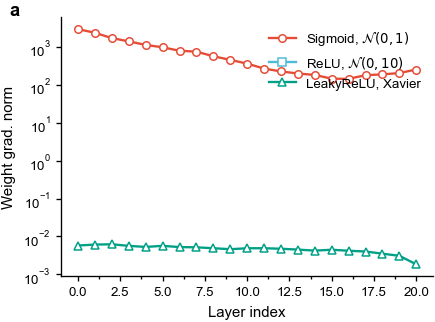

d:\Anaconda\conda\Lib\site-packages\IPython\core\events.py:82: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)


In [31]:
layer_idx = np.arange(len(sigmoid_norms))
labels = ['Sigmoid, $\\mathcal{N}(0,1)$', 'ReLU, $\\mathcal{N}(0,10)$', 'LeakyReLU, Xavier']
series = [sigmoid_norms, relu_big_norms, xavier_norms]
markers = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(4.0, 2.8))
for i, (y, lab, mk) in enumerate(zip(series, labels, markers)):
    ax.semilogy(layer_idx, np.maximum(y, 1e-30), color=NATURE_COLORS[i], marker=mk,
                markerfacecolor='white', markeredgewidth=0.9, markersize=4.5, label=lab)
ax.set(xlabel='Layer index', ylabel='Weight grad. norm')
style_axes(ax, panel='a')
ax.legend(loc='upper right', frameon=False)
save_nature_fig(fig, 'fig3_gradient_norms.pdf')
save_nature_fig(fig, 'fig3_gradient_norms.png')

def check_grad_stability(norms, low=1e-6, high=1e3):
    """判断梯度范数是否有限且落在合理区间。"""
    norms = np.array(norms, dtype=float)
    finite = np.isfinite(norms).all()
    in_range_ratio = np.mean((norms >= low) & (norms <= high))
    stable = finite and in_range_ratio >= 0.8
    return finite, in_range_ratio, stable

print('\n梯度稳定性自动判断 (合理区间: [{:.0e}, {:.0e}])'.format(1e-6, 1e3))
stability_rows = []
for name, norms in zip(labels, series):
    finite, ratio, stable = check_grad_stability(norms)
    stability_rows.append({
        'Configuration': name,
        'All Finite': finite,
        'Stable Ratio': round(ratio, 2),
        'Stable?': 'Yes' if stable else 'No',
    })
    print(f'{name}: finite={finite}, stable ratio={ratio:.2f}, stable={stable}')
grad_stability_df = pd.DataFrame(stability_rows)
display(grad_stability_df.style.hide(axis='index'))
fig


**结果分析：** Sigmoid 网络在深层结构中易出现前面层梯度接近 0；ReLU 配合过大初始化可能产生极大梯度甚至 NaN；Xavier 初始化后梯度范数更稳定。下图给出 20 层网络的梯度范数对比；**梯度稳定性自动判断表**从“是否有限”与“是否落在 $[10^{-6},10^3]$”两个维度给出定量结论，便于与图示相互印证。


---
# 5 泛化表现、协变量偏移和对抗性数据

## 5.1 理论计算题

协变量偏移指训练分布和测试分布中的输入分布不同，但条件分布不变：

$$p(x)\ne q(x),\qquad p(y|x)=q(y|x)$$

例如医疗影像中，训练数据来自 A 医院，测试数据来自 B 医院。由于设备参数、扫描协议和患者来源不同，图像分布发生变化；但同样影像特征对应的疾病标签规律基本一致。

标签偏移指训练分布和测试分布中的标签先验不同，但类别条件分布不变：

$$p(y)\ne q(y),\qquad p(x|y)=q(x|y)$$

例如电商平台在普通时期和大促时期，不同商品类别的购买比例发生变化，但在给定商品类别后，用户行为特征分布相对类似。

二者联系在于都属于训练环境和测试环境不一致的非平稳问题，都会影响模型泛化表现；区别在于协变量偏移主要改变输入 $x$ 的分布，标签偏移主要改变类别 $y$ 的先验分布。


## 5.2 编程题：模拟协变量偏移并使用权重修正

训练集 $P:x\sim N(-1,1)$，测试集 $Q:x\sim N(2,1)$，标签生成关系均为 $y=2x+\epsilon$。通过逻辑回归估计 $P(test|x)$，再计算权重 $w_i\propto P(test|x_i)/P(train|x_i)$，最后进行加权最小二乘。

> **关键说明：** 本实验中真实关系为线性 $y=2x+\epsilon$，基线模型也采用线性回归，因此**模型设定与真实机制一致**。在存在协变量偏移时，OLS 仍可能取得较低测试 MSE；重要性加权不一定每次都能显著降低 MSE，但实验完整展示了「域分类 → 密度比权重 → 加权训练 → 对比评估」的流程。


已保存: e:\study\class\深度学习\figures\fig4a_covariate_shift.pdf


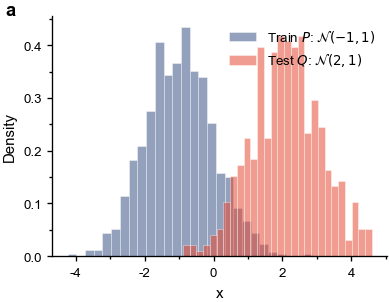

In [32]:
np.random.seed(SEED)
n_train, n_test = 1000, 500
x_p = np.random.normal(-1, 1, size=(n_train, 1))
x_q = np.random.normal(2, 1, size=(n_test, 1))
y_p = 2 * x_p + np.random.normal(0, 0.3, size=(n_train, 1))
y_q = 2 * x_q + np.random.normal(0, 0.3, size=(n_test, 1))

fig, ax = plt.subplots(figsize=(3.6, 2.6))
ax.hist(x_p.ravel(), bins=28, density=True, alpha=0.55, color=NATURE_COLORS[3],
        edgecolor='white', linewidth=0.4, label=r'Train $P$: $\mathcal{N}(-1,1)$')
ax.hist(x_q.ravel(), bins=28, density=True, alpha=0.55, color=NATURE_COLORS[0],
        edgecolor='white', linewidth=0.4, label=r'Test $Q$: $\mathcal{N}(2,1)$')
ax.set(xlabel='x', ylabel='Density')
style_axes(ax, panel='a')
ax.legend(loc='upper right')
save_nature_fig(fig, 'fig4a_covariate_shift.pdf')
fig


In [15]:
def add_bias(x):
    return np.concatenate([np.ones((x.shape[0], 1)), x], axis=1)

def mse_np(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

X_p, X_q = add_bias(x_p), add_bias(x_q)
theta_ols = np.linalg.pinv(X_p.T @ X_p) @ X_p.T @ y_p
mse_ols = mse_np(y_q, X_q @ theta_ols)
print('基线线性回归参数:', theta_ols.ravel())
print('基线测试 MSE:', round(mse_ols, 6))


基线线性回归参数: [0.01637987 2.01338795]
基线测试 MSE: 0.092669


In [16]:
# 手写逻辑回归域分类器：train=0, test=1
X_domain = np.vstack([x_p, x_q])
y_domain = np.vstack([np.zeros((n_train, 1)), np.ones((n_test, 1))])
X_domain_b = add_bias(X_domain)

w_domain = np.zeros((2, 1))
for _ in range(3000):
    logits = X_domain_b @ w_domain
    probs = 1 / (1 + np.exp(-logits))
    grad = X_domain_b.T @ (probs - y_domain) / len(y_domain)
    w_domain -= 0.1 * grad

p_test = 1 / (1 + np.exp(-add_bias(x_p) @ w_domain))
p_train = 1 - p_test
weights = (p_test / (p_train + 1e-8)).ravel()
weights = np.clip(weights, 0, np.percentile(weights, 99))
weights = weights / weights.mean()

print('域分类器参数:', w_domain.ravel())
print('权重统计: min=%.4f, mean=%.4f, max=%.4f' % (weights.min(), weights.mean(), weights.max()))


域分类器参数: [-2.32313008  2.9776032 ]
权重统计: min=0.0000, mean=1.0000, max=29.9963


加权线性回归参数: [0.05938816 1.90851907]
加权测试 MSE: 0.120048
MSE 改变量 baseline - weighted: -0.027379
已保存: e:\study\class\深度学习\figures\fig4b_importance_weighting.pdf
已保存: e:\study\class\深度学习\figures\fig4b_importance_weighting.png


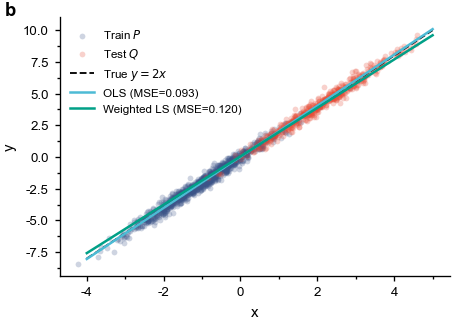

In [33]:
W = np.diag(weights)
theta_wls = np.linalg.pinv(X_p.T @ W @ X_p) @ X_p.T @ W @ y_p
mse_wls = mse_np(y_q, X_q @ theta_wls)
print('加权线性回归参数:', theta_wls.ravel())
print('加权测试 MSE:', round(mse_wls, 6))
print('MSE 改变量 baseline - weighted:', round(mse_ols - mse_wls, 6))

fig, ax = plt.subplots(figsize=(4.2, 2.8))
ax.scatter(x_p, y_p, s=12, alpha=0.25, color=NATURE_COLORS[3], linewidths=0, label='Train $P$')
ax.scatter(x_q, y_q, s=12, alpha=0.25, color=NATURE_COLORS[0], linewidths=0, label='Test $Q$')
x_line = np.linspace(-4, 5, 200).reshape(-1, 1)
X_line = add_bias(x_line)
ax.plot(x_line, 2 * x_line, color='black', linestyle='--', linewidth=1.1, label=r'True $y=2x$')
ax.plot(x_line, X_line @ theta_ols, color=NATURE_COLORS[1], linewidth=1.5,
        label=f'OLS (MSE={mse_ols:.3f})')
ax.plot(x_line, X_line @ theta_wls, color=NATURE_COLORS[2], linewidth=1.5,
        label=f'Weighted LS (MSE={mse_wls:.3f})')
ax.set(xlabel='x', ylabel='y')
style_axes(ax, panel='b')
ax.legend(loc='upper left', fontsize=7)
save_nature_fig(fig, 'fig4b_importance_weighting.pdf')
save_nature_fig(fig, 'fig4b_importance_weighting.png')
fig


**结果分析：** 训练集与测试集的输入分布明显不同，域分类器与直方图均支持存在协变量偏移。加权最小二乘让模型更关注“像测试分布”的训练样本。由于真实关系为线性且基线亦为线性回归，OLS 已较合适，故加权校正未必大幅优于 OLS；这不削弱实验价值，反而说明**分布偏移与模型错配需分开讨论**。


---
# 作业总结

本次作业围绕**多层感知机、模型选择、数值稳定性与分布偏移**展开，主要结论如下：

1. **理论部分**：证明了隐藏层非线性的必要性；推导 Sigmoid/tanh 导数；说明 K 折交叉验证流程；分析梯度消失/爆炸与协变量偏移、标签偏移的区别。
2. **Fashion-MNIST MLP（10 epoch）**：从零实现前向、损失与 SGD；训练/测试准确率同步提升；损失与准确率曲线见 `figures/fig1_*`。
3. **正则化实验**：对比无正则、权重衰减与 Dropout；结果表给出 Final Train/Val Loss 与 Generalization Gap；权重衰减与 Dropout 通常缓解过拟合。
4. **数值稳定性**：Sigmoid 深层网络易出现梯度消失；ReLU+过大初始化可能梯度爆炸/NaN；Xavier+LeakyReLU 更稳定；自动判断表量化“是否稳定”。
5. **协变量偏移**：完成重要性加权流程；在线性真机制下 OLS 已较强，加权未必显著降 MSE，但体现了偏移场景下的标准修正思路。

总体而言，深度学习模型的泛化能力不仅依赖网络结构，还受**正则化、初始化与数据分布一致性**共同影响。
